# Modelo de Machine Learning — previsão diária de `qt_material`

**Objetivo:** prever `qt_material` por **dia × canal × categoria** com **14 dias de antecedência**, usando o que aprendemos na análise exploratória (`analise_exploratoria.ipynb`).

**Premissas acordadas**
- **Grão:** dia × canal (App, Site) × categoria, sem horário. O total do dia é a soma das séries.
- **Correções de dados** na query de modelagem: receita negativa com `ABS`, duas casas decimais com `ROUND`, categoria inválida recuperada quando só falta uma categoria naquela hora × canal.
- **Datas comemorativas:** uma coluna por data (Black Friday, Natal, Ano Novo, Dia do Consumidor, Dia das Mães, Dia dos Namorados), ligada na semana anterior e no dia do evento. As datas são calculadas por regra, então a próxima Black Friday já tem flag.
- **Black November:** coluna própria, da primeira segunda-feira de novembro ao domingo após a Black Friday, também por regra.
- **Campanha:** coluna para campanhas pontuais informadas pelo negócio. Por premissa, a campanha de maio (15 a 24/05/2026).
- **Desconto:** não conhecemos o desconto realizado no futuro, mas o time responsável informa a **taxa média de desconto prevista para cada categoria em cada semana**. No histórico usamos a taxa realizada da categoria na semana.
- **Validação faseada:** treina com cerca de 5 meses, prevê 2 semanas, acrescenta essas 2 semanas ao treino e repete até o fim da base.
- **Escolha do modelo em duas etapas:**
  - **Etapa 1:** os três modelos com parâmetros padrão, para uma comparação justa.
  - **Etapa 2:** só o vencedor é ajustado, e cada rodada escolhe os parâmetros usando apenas o próprio passado.

**Roteiro:** 1. Base de modelagem · 2. Features · 3. Validação faseada · 4. Baselines · 5. Etapa 1: parâmetros padrão · 6. Comparação da etapa 1 · 7. Etapa 2: ajuste do vencedor · 8. Resultado final · 9. SHAP · 10. Sensibilidade ao desconto · 11. Conclusões

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

# Validação faseada: o teste começa depois de 5 meses de treino
INICIO_TESTE = "2026-04-01"

COR_REAL = "#333333"
CORES_MODELO = {
    "naive_sazonal": "#9e9e9e",
    "mm7": "#bdbdbd",
    "mm28": "#757575",
    "regressao_linear": "#1f4e79",
    "lightgbm": "#6a994e",
    "xgboost": "#d17a22",
    "vencedor_ajustado": "#a23b72",
}

## Consumo BigQuery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados. As consultas ficam na pasta `sql/`, numeradas na ordem de uso no projeto: este notebook continua a numeração da análise exploratória (`42_sql_base_modelagem.sql`, `43_sql_conferencia_modelagem.sql`).

In [2]:
from pathlib import Path


def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(sql, project_id=PROJECT_ID, location=BQ_LOCATION)
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")
    return read_query(sql, project_id=PROJECT_ID, location=BQ_LOCATION)


PASTA_SQL = next(
    pasta / "sql" for pasta in [Path.cwd(), *Path.cwd().parents] if (pasta / "sql").is_dir()
)


def carregar_sql(arquivo: str, **parametros) -> str:
    """Lê sql/<arquivo> e preenche os parâmetros {TABLE_ID}, {DATE_FILTER} etc."""
    modelo = (PASTA_SQL / arquivo).read_text(encoding="utf-8")
    return modelo.format(
        TABLE_ID=TABLE_ID,
        STG_TABLE_ID=STG_TABLE_ID,
        DATE_FILTER=DATE_FILTER,
        START_DATE=START_DATE,
        END_DATE=END_DATE,
        **parametros,
    )

# 1. Base de modelagem

A query `42_sql_base_modelagem.sql` aplica as correções identificadas na análise exploratória e entrega o grão do modelo:

| Problema (seção da análise exploratória) | Correção |
|---|---|
| Receita negativa é erro de sinal (2.4) | `ABS(receita_aprovada)` |
| Valores monetários com mais de 2 casas (2.6) | `ROUND(..., 2)` em receita e desconto |
| Categoria com código numérico (2.3) | recebe a única categoria que falta naquela hora × canal; se houver 2 ou mais candidatas, vira `NAO_IDENTIFICADA` |
| Dias sem venda de uma série | grade completa dia × canal × categoria, com zero |

Ela também calcula `taxa_desconto_semana_categoria` = desconto ÷ (receita + desconto) da categoria na semana (segunda a domingo, os dois canais juntos). É a mesma definição de taxa de desconto da análise exploratória, no nível que o time de desconto informaria para as semanas futuras.

In [3]:
sql_base_modelagem = carregar_sql("42_sql_base_modelagem.sql")

base = run_bq(sql_base_modelagem, "base de modelagem: dia x canal x categoria")
base["data"] = pd.to_datetime(base["data"])
base["qt_material"] = base["qt_material"].astype(float)

print(f"{len(base):,} linhas | {base['data'].nunique()} dias | "
      f"{base.groupby(['des_canal_venda_final_agrup', 'des_categoria_material']).ngroups} séries")
display(base.head())

[BigQuery] base de modelagem: dia x canal x categoria | estimativa processada: 5.87 MB


4,356 linhas | 242 dias | 18 séries


,data,des_canal_venda_final_agrup,des_categoria_material,qt_material,receita_aprovada,vlr_venda_desconto,taxa_desconto_semana_categoria
0,2025-11-01,App,CABELOS,769.0000,"26,428.9400","6,110.8200",0.3513
1,2025-11-01,App,CORPO E BANHO,"3,386.0000","149,964.9600","63,001.6900",0.2855
2,2025-11-01,App,FACIAL,370.0000,"14,032.6200","9,897.4200",0.4769
3,2025-11-01,App,GIFTS,"1,725.0000","153,963.0300","69,794.1300",0.3134
4,2025-11-01,App,MAQUIAGEM,"2,393.0000","69,248.0000","48,388.1000",0.4066


### Conferência da base

A base corrigida precisa ter **o mesmo volume** da tabela original: as correções só redistribuem categorias e ajustam sinal e centavos, não podem criar nem perder `qt_material`.

In [4]:
sql_conferencia_modelagem = carregar_sql("43_sql_conferencia_modelagem.sql")
original = run_bq(sql_conferencia_modelagem, "totais da tabela original").iloc[0]

conferencia = pd.DataFrame({
    "tabela original": original[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].astype(float),
    "base de modelagem": base[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].sum(),
})
conferencia["diferença"] = conferencia["base de modelagem"] - conferencia["tabela original"]
display(conferencia)

qt_invalida = float(original["qt_categoria_invalida"])
qt_nao_identificada = base.loc[base["des_categoria_material"] == "NAO_IDENTIFICADA", "qt_material"].sum()
print(f"qt_material com categoria inválida: {qt_invalida:,.0f}")
print(f"recuperada para uma categoria:      {qt_invalida - qt_nao_identificada:,.0f} "
      f"({1 - qt_nao_identificada / qt_invalida:.1%})")
print(f"ficou como NAO_IDENTIFICADA:        {qt_nao_identificada:,.0f} "
      f"({qt_nao_identificada / base['qt_material'].sum():.1%} do volume total)")
assert abs(conferencia.loc["qt_material", "diferença"]) < 1e-6, "a base perdeu ou duplicou volume"

[BigQuery] totais da tabela original | estimativa processada: 5.41 MB


,tabela original,base de modelagem,diferença
qt_material,"9,896,201.0000","9,896,201.0000",0.0000
receita_aprovada,"532,413,485.7000","532,413,485.7000",0.0000
vlr_venda_desconto,"379,767,342.7800","379,767,342.7800",0.0000


qt_material com categoria inválida: 583,622
recuperada para uma categoria:      364,511 (62.5%)
ficou como NAO_IDENTIFICADA:        219,111 (2.2% do volume total)


### Diagnóstico

- **Volume preservado:** `qt_material`, receita e desconto batem exatamente com a tabela original. As correções não criaram nem perderam volume.
- **Categoria inválida:** 62,5% do volume com código numérico (364 mil de 584 mil unidades) foi recuperado para a única categoria possível. O restante (219 mil, 2,2% do volume total) ficou como `NAO_IDENTIFICADA` e é previsto como uma série própria. Assim o total do dia continua completo.
- **Grão final:** 242 dias × 2 canais × 9 categorias = 4.356 linhas, 18 séries sem buracos de datas.

# 2. Features

| Feature | Tipo | Por quê |
|---|---|---|
| `is_app` | dummy (App = 1, Site = 0) | nível de volume diferente por canal |
| `cat_*` | dummies de categoria | nível de volume diferente por categoria |
| `dia_semana` | 0 = segunda ... 6 = domingo (dummies na regressão linear) | padrão semanal forte (seção 1.5 da análise exploratória) |
| `dia_mes` | 1 a 31 (só nas árvores) | possível efeito de início/fim de mês |
| `evento_*` | uma coluna por data comemorativa: 1 na semana anterior e no dia | a alta começa antes da data |
| `black_november` | 1 da primeira segunda-feira de novembro ao domingo após a Black Friday | o mês inteiro fica 3 a 4× acima do normal |
| `campanha` | 1 nas campanhas pontuais informadas pelo negócio | campanha de maio |
| `taxa_desconto_semana_categoria` | taxa média de desconto da categoria na semana | premissa: informada pelo time de desconto |
| `lag_14`, `lag_21`, `lag_28`, `mm7_lag14`, `mm28_lag14` | histórico da própria série (só nas árvores; testado como parâmetro na etapa 2) | nível recente da série; todos com pelo menos 14 dias de atraso, porque a previsão é feita 14 dias antes |

**Mês e ano não são usados nesta versão.** Com 8 meses de base, cada mês aparece uma única vez, e o modelo usaria o mês para decorar o que aconteceu nele: novembro viraria a Black November, maio a campanha. Nos testes, incluir mês e ano piorou as árvores em 5 a 7 pontos de WAPE. Na regressão linear, o mês numérico vira uma reta de tendência que extrapolaria valores irreais. **Quando a base tiver 2 anos ou mais**, mês e ano devem entrar no retreino, porque aí o mês passa a captar a sazonalidade anual de verdade.

**Também ficam de fora `nr_pedidos` e a receita do mesmo dia:** são resultado da venda e não estão disponíveis no momento da previsão.

In [5]:
from gb_ml.features import (
    CAMPANHAS, COLUNA_DESCONTO, montar_features, periodo_black_november, tabela_eventos,
)

df = montar_features(base)

eventos = tabela_eventos([2025, 2026])
eventos["na base"] = eventos["data"].between(START_DATE, END_DATE)
print("Datas comemorativas (a flag fica ligada de inicio_flag até fim_flag):")
display(eventos.sort_values("data").reset_index(drop=True))

black_november = pd.DataFrame(
    [(ano, *periodo_black_november(ano)) for ano in [2025, 2026]], columns=["ano", "inicio", "fim"]
)
print("Black November (por regra):")
display(black_november)
print("Campanhas pontuais (premissa do negócio):")
display(pd.DataFrame(CAMPANHAS, columns=["campanha", "inicio", "fim"]))

Datas comemorativas (a flag fica ligada de inicio_flag até fim_flag):


,evento,data,inicio_flag,fim_flag,na base
0,ano_novo,2025-01-01,2024-12-25,2025-01-01,False
1,dia_consumidor,2025-03-15,2025-03-08,2025-03-15,False
2,dia_maes,2025-05-11,2025-05-04,2025-05-11,False
3,dia_namorados,2025-06-12,2025-06-05,2025-06-12,False
4,black_friday,2025-11-28,2025-11-21,2025-11-28,True
5,natal,2025-12-25,2025-12-18,2025-12-25,True
6,ano_novo,2026-01-01,2025-12-25,2026-01-01,True
7,dia_consumidor,2026-03-15,2026-03-08,2026-03-15,True
8,dia_maes,2026-05-10,2026-05-03,2026-05-10,True
9,dia_namorados,2026-06-12,2026-06-05,2026-06-12,True


Black November (por regra):


,ano,inicio,fim
0,2025,2025-11-03,2025-11-30
1,2026,2026-11-02,2026-11-29


Campanhas pontuais (premissa do negócio):


,campanha,inicio,fim
0,campanha_maio,2026-05-15,2026-05-24


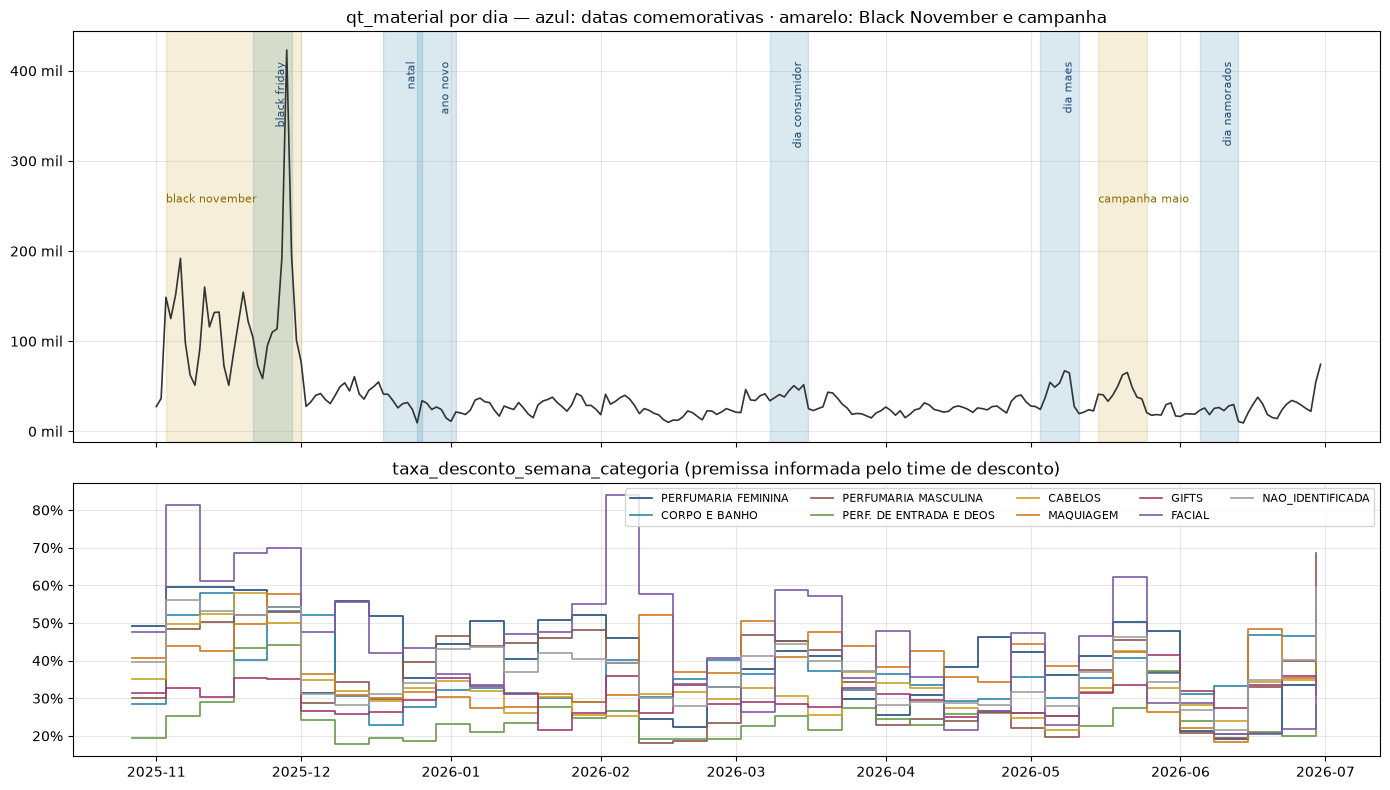

In [6]:
total_dia = df.groupby("data")["qt_material"].sum()
desconto_semana = (
    df.groupby([df["data"].dt.to_period("W-SUN").dt.start_time, "des_categoria_material"])[COLUNA_DESCONTO]
    .first().unstack()
)
categorias = df.groupby("des_categoria_material")["qt_material"].sum().sort_values(ascending=False).index
paleta = ["#1f4e79", "#2e86ab", "#8c564b", "#6a994e", "#c9a227", "#d17a22", "#a23b72", "#7d5ba6", "#9e9e9e"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(total_dia.index, total_dia, color=COR_REAL, lw=1.2)
topo = total_dia.max()
for _, ev in eventos[eventos["na base"]].iterrows():
    ax1.axvspan(ev["inicio_flag"], ev["fim_flag"] + pd.Timedelta(days=1), color="#2e86ab", alpha=0.18)
    ax1.text(ev["data"], topo * 0.97, ev["evento"].replace("_", " "),
             rotation=90, va="top", ha="right", fontsize=8, color="#1f4e79")
periodos = [("black november", *periodo_black_november(2025))] + [
    (nome.replace("_", " "), inicio, fim) for nome, inicio, fim in CAMPANHAS
]
for nome, inicio, fim in periodos:
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fim) + pd.Timedelta(days=1), color="#c9a227", alpha=0.18)
    ax1.text(pd.Timestamp(inicio), topo * 0.6, nome, fontsize=8, color="#8a6d00")
ax1.set_title("qt_material por dia — azul: datas comemorativas · amarelo: Black November e campanha")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
ax1.grid(alpha=0.3)

for categoria, cor in zip(categorias, paleta):
    ax2.step(desconto_semana.index, desconto_semana[categoria], where="post", color=cor, lw=1.2, label=categoria)
ax2.set_title("taxa_desconto_semana_categoria (premissa informada pelo time de desconto)")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.legend(ncol=5, fontsize=8, loc="upper right")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Black November** domina o gráfico: o mês inteiro ficou de 3 a 4 vezes acima do resto da base, e a Black Friday (28/11) chegou a 423 mil. Agora ela tem coluna própria, separada da campanha de maio, que foi bem menor (cerca de 2×).
- **O desconto varia muito entre categorias:** Facial passa de 80% em algumas semanas, enquanto Perf. de Entrada e Deos fica perto de 20%. Por isso a premissa por categoria é mais informativa que uma taxa única para todas.
- **Dia das Mães** (03 a 10/05) aparece pela **primeira vez** dentro do período de teste. O modelo ainda não tem exemplo desse evento quando precisa prevê-lo (ver seção 6).

# 3. Validação faseada

Simula o uso real: em cada rodada o modelo treina com **tudo que aconteceu até a véspera**, prevê os **próximos 14 dias** e só depois recebe esses 14 dias para a rodada seguinte (janela expansível). São 7 rodadas, de 01/04 a 30/06, com cerca de 5 meses de treino na primeira. A última rodada tem só 7 dias, porque a base termina em 30/06.

**Escolha do modelo em duas etapas**
1. **Etapa 1 — parâmetros padrão:** os três modelos rodam com os parâmetros padrão das bibliotecas, sem nenhum ajuste. É uma comparação justa, porque nenhum modelo se beneficia de ajuste.
2. **Etapa 2 — ajuste do vencedor:** antes de prever cada rodada, o vencedor testa uma grade de parâmetros nas 3 janelas de 14 dias anteriores a ela, usando só dados até a véspera, e usa a melhor combinação para prever a rodada. Os parâmetros nunca são escolhidos com os dias que o modelo precisa acertar, então o erro reportado é honesto.

**Métricas** (sempre sobre o período previsto)
- **WAPE** = Σ|erro| ÷ Σ real, a métrica principal. É calculado em dois níveis: por série (dia × canal × categoria) e no total do dia.
- **MAE** do total do dia, em unidades.
- **Viés** = Σ(previsto − real) ÷ Σ real. Positivo significa que o modelo superestima.
- **Skill** = 1 − WAPE do modelo ÷ WAPE do melhor baseline. Acima de zero, o modelo ganha do baseline.

,rodada,inicio,fim,dias_de_treino
0,1,2026-04-01,2026-04-14,151
1,2,2026-04-15,2026-04-28,165
2,3,2026-04-29,2026-05-12,179
3,4,2026-05-13,2026-05-26,193
4,5,2026-05-27,2026-06-09,207
5,6,2026-06-10,2026-06-23,221
6,7,2026-06-24,2026-06-30,235


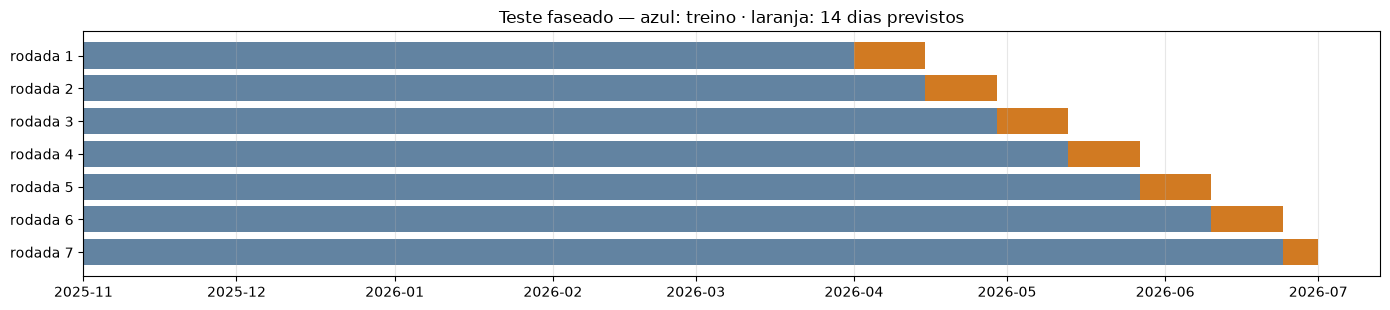

In [7]:
from gb_ml.model import (
    backtest_com_ajuste, baseline, buscar_parametros, erro_por_rodada, folds_de_ajuste,
    gerar_folds, resumo_backtest, rodar_backtest,
)

folds_teste = gerar_folds(INICIO_TESTE, END_DATE)
display(folds_teste.assign(dias_de_treino=(folds_teste["inicio"] - pd.Timestamp(START_DATE)).dt.days))

fig, ax = plt.subplots(figsize=(14, 3.2))
for i, f in folds_teste.iterrows():
    y = len(folds_teste) - i
    ax.barh(y, (f["inicio"] - pd.Timestamp(START_DATE)).days, left=pd.Timestamp(START_DATE), color="#1f4e79", alpha=0.7)
    ax.barh(y, (f["fim"] - f["inicio"]).days + 1, left=f["inicio"], color="#d17a22")
ax.set_yticks(range(1, len(folds_teste) + 1), [f"rodada {r}" for r in folds_teste["rodada"][::-1]])
ax.set_title("Teste faseado — azul: treino · laranja: 14 dias previstos")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Baselines

Referências simples, calculadas por série com o histórico até a véspera de cada rodada (as médias móveis vêm da análise exploratória):
- **naive_sazonal**: repete a última semana observada, mantendo o dia da semana;
- **mm7** e **mm28**: média dos últimos 7 e 28 dias, constante nos 14 dias.

Um modelo só se justifica se tiver erro menor que o do melhor baseline.

In [8]:
previsoes = {}
for metodo in ["naive_sazonal", "mm7", "mm28"]:
    previsoes[metodo] = rodar_backtest(df, folds_teste, baseline(metodo))

resumo_baselines = pd.DataFrame({m: resumo_backtest(p) for m, p in previsoes.items()}).T
display(resumo_baselines)
MELHOR_BASELINE = resumo_baselines["wape_dia"].idxmin()
print(f"Melhor baseline (WAPE do total do dia): {MELHOR_BASELINE}")

,wape_serie,wape_dia,mae_dia,vies_dia
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027
mm7,0.5147,0.3576,"10,525.9011",-0.0027
mm28,0.5241,0.3868,"11,384.5137",0.0169


Melhor baseline (WAPE do total do dia): mm7


# 5. Etapa 1 — os três modelos com parâmetros padrão

| Modelo | Configuração padrão |
|---|---|
| **Regressão linear** | mínimos quadrados, alvo em `log(1 + qt_material)` (efeitos multiplicativos), sem interação, erros-padrão robustos (HC1) |
| **LightGBM** | parâmetros padrão da biblioteca (100 árvores, 31 folhas, `learning_rate` 0,1), objetivo Poisson (alvo de contagem), sem lags |
| **XGBoost** | parâmetros padrão da biblioteca (100 árvores, profundidade 6, `learning_rate` 0,3), objetivo Poisson, sem lags |

O alvo em log e o objetivo Poisson são escolhas de modelagem, não ajuste fino. Os dois fazem os efeitos serem proporcionais ao nível de cada série, já que o volume de novembro é 4× o do resto da base. Lags, tipo de alvo e demais parâmetros são testados na etapa 2.

In [9]:
from gb_ml.model import ajustar_linear, criar_lightgbm, criar_xgboost, lightgbm, linear, xgboost

FABRICAS = {"regressao_linear": linear, "lightgbm": lightgbm, "xgboost": xgboost}
PADRAO = {
    "regressao_linear": {"alvo": "log", "interacao": False},
    "lightgbm": {"alvo": "poisson", "usar_lags": False},
    "xgboost": {"alvo": "poisson", "usar_lags": False},
}
for nome, fabrica in FABRICAS.items():
    previsoes[nome] = rodar_backtest(df, folds_teste, fabrica(**PADRAO[nome]))

display(pd.DataFrame({nome: resumo_backtest(previsoes[nome]) for nome in FABRICAS}).T)

,wape_serie,wape_dia,mae_dia,vies_dia
regressao_linear,0.3770,0.2718,"8,001.6035",-0.1593
lightgbm,0.3793,0.2553,"7,514.5808",-0.0739
xgboost,0.3834,0.2638,"7,763.8029",-0.0931


In [10]:
def plot_real_previsto(modelos: list[str], titulo: str) -> None:
    """Total do dia: real × previsto por modelo, com as divisões das rodadas."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    real = previsoes[modelos[0]].groupby("data")["qt_material"].sum()
    ax.plot(real.index, real, color=COR_REAL, lw=2, label="real")
    for modelo in modelos:
        previsto = previsoes[modelo].groupby("data")["previsto"].sum()
        ax.plot(previsto.index, previsto, color=CORES_MODELO[modelo], lw=1.5, label=modelo)
    for inicio in folds_teste["inicio"]:
        ax.axvline(inicio, color="#999999", ls=":", lw=1)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def treinar_arvore(nome: str, parametros: dict):
    """Treina LightGBM/XGBoost com toda a base; devolve o modelo, a matriz e a previsão em qt_material."""
    from gb_ml.features import matriz_arvore

    criar = {"lightgbm": criar_lightgbm, "xgboost": criar_xgboost}[nome]
    extras = {k: v for k, v in parametros.items() if k not in ("alvo", "usar_lags")}
    X = matriz_arvore(df, parametros["usar_lags"])
    y = np.log1p(df["qt_material"]) if parametros["alvo"] == "log" else df["qt_material"]
    modelo = criar(parametros["alvo"], **extras).fit(X, y)
    previsto = modelo.predict(X)
    return modelo, X, np.expm1(previsto) if parametros["alvo"] == "log" else previsto

## 5.1 Regressão linear

### Curva: real × previsto no teste faseado

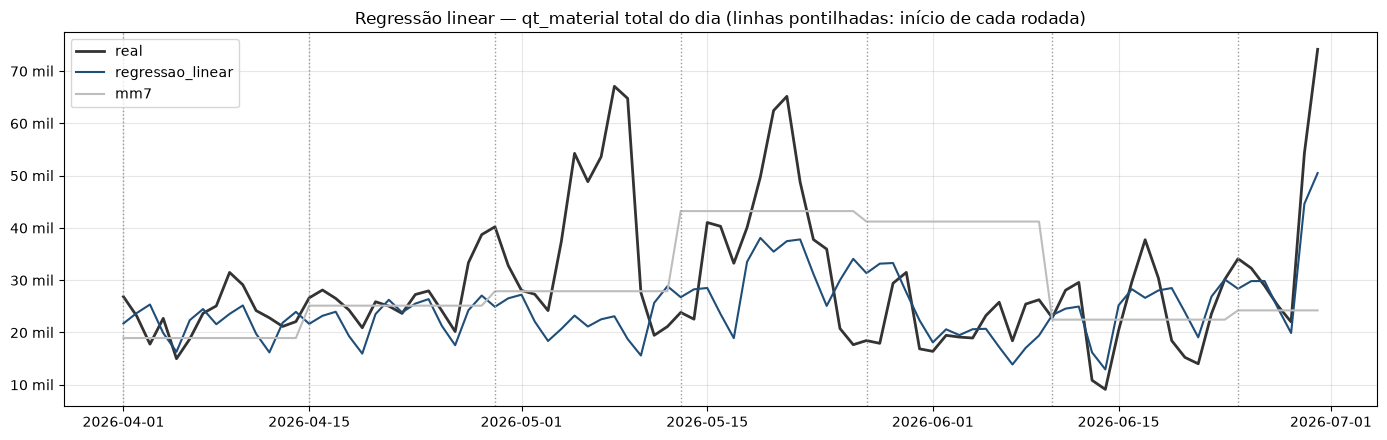

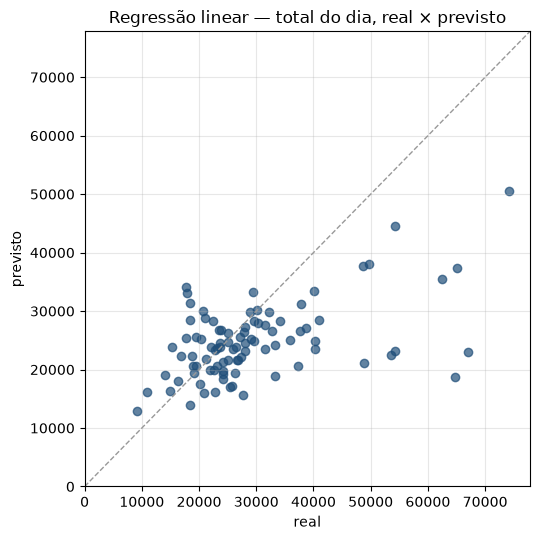

In [11]:
plot_real_previsto(["regressao_linear", MELHOR_BASELINE],
                   "Regressão linear — qt_material total do dia (linhas pontilhadas: início de cada rodada)")

total_linear = previsoes["regressao_linear"].groupby("data")[["qt_material", "previsto"]].sum()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(total_linear["qt_material"], total_linear["previsto"], color=CORES_MODELO["regressao_linear"], alpha=0.7)
limite = total_linear.to_numpy().max() * 1.05
ax.plot([0, limite], [0, limite], color="#999999", ls="--", lw=1)
ax.set(xlim=(0, limite), ylim=(0, limite), xlabel="real", ylabel="previsto",
       title="Regressão linear — total do dia, real × previsto")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados estatísticos da regressão

Modelo ajustado com **toda a base** (01/11 a 30/06). Como o alvo está em log, **efeito %** = e^coeficiente − 1 é a variação de volume quando a feature vale 1, mantendo as demais constantes. Para a taxa de desconto, o efeito é para **+10 pontos percentuais**.

In [12]:
modelo_linear = ajustar_linear(df, **PADRAO["regressao_linear"])
print(f"R² = {modelo_linear.rsquared:.3f} | R² ajustado = {modelo_linear.rsquared_adj:.3f} | "
      f"n = {int(modelo_linear.nobs):,} | alvo = log(1 + qt_material)")

ic = modelo_linear.conf_int()
coeficientes = pd.DataFrame({
    "coeficiente": modelo_linear.params,
    "ic95_inf": ic[0],
    "ic95_sup": ic[1],
    "p_valor": modelo_linear.pvalues,
})
escala = pd.Series(1.0, index=coeficientes.index)
escala[COLUNA_DESCONTO] = 0.10  # efeito de +10 p.p. de desconto
for coluna in ["coeficiente", "ic95_inf", "ic95_sup"]:
    coeficientes[f"efeito_%_{coluna}"] = np.expm1(coeficientes[coluna] * escala)
coeficientes["significativo_5%"] = coeficientes["p_valor"] < 0.05
display(coeficientes.drop(index="const"))

R² = 0.746 | R² ajustado = 0.744 | n = 4,356 | alvo = log(1 + qt_material)


,coeficiente,ic95_inf,ic95_sup,p_valor,efeito_%_coeficiente,efeito_%_ic95_inf,efeito_%_ic95_sup,significativo_5%
is_app,1.1919,1.1473,1.2365,0.0000,2.2933,2.1496,2.4435,True
taxa_desconto_semana_categoria,3.8834,3.6417,4.1251,0.0000,0.4745,0.4393,0.5106,True
evento_ano_novo,-0.3304,-0.4669,-0.1939,0.0000,-0.2814,-0.3731,-0.1762,True
evento_dia_consumidor,0.1791,0.0387,0.3195,0.0124,0.1962,0.0395,0.3765,True
evento_dia_maes,0.6094,0.4947,0.7242,0.0000,0.8394,0.6400,1.0630,True
evento_dia_namorados,0.3287,0.2439,0.4134,0.0000,0.3891,0.2762,0.5119,True
evento_black_friday,-0.0122,-0.2157,0.1913,0.9063,-0.0121,-0.1941,0.2108,False
evento_natal,0.1247,-0.0118,0.2612,0.0734,0.1328,-0.0117,0.2985,False
black_november,0.8190,0.7216,0.9163,0.0000,1.2682,1.0578,1.5001,True
campanha,0.3031,0.1866,0.4196,0.0000,0.3540,0.2051,0.5213,True


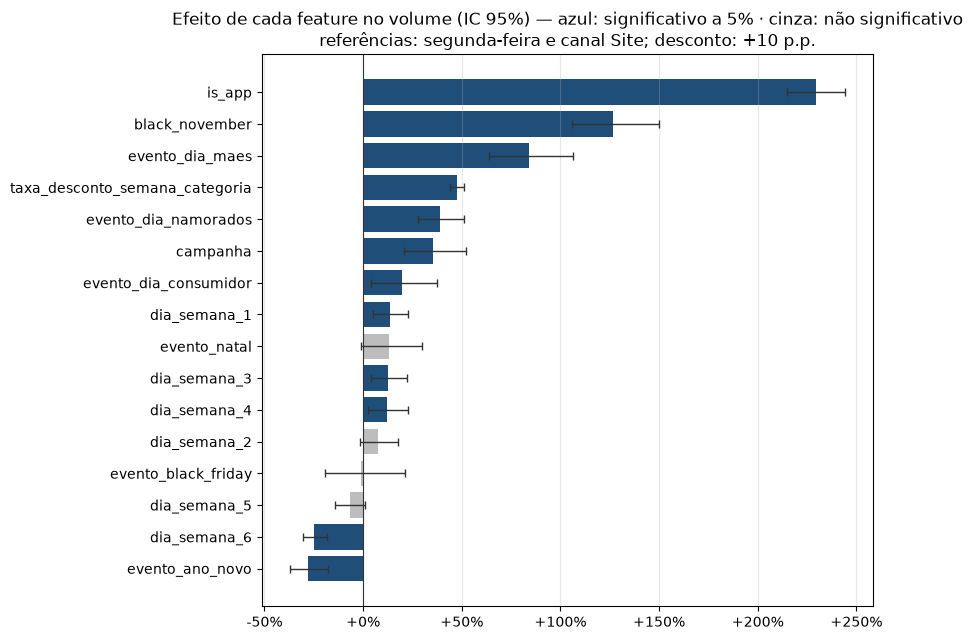

In [13]:
grupos_coef = [c for c in coeficientes.index
               if c.startswith(("evento_", "black_november", "campanha", "taxa_", "dia_semana_", "is_app"))]
efeito = coeficientes.loc[grupos_coef].sort_values("efeito_%_coeficiente")

fig, ax = plt.subplots(figsize=(9, 6.5))
cores_barra = np.where(efeito["significativo_5%"], "#1f4e79", "#bdbdbd")
ax.barh(efeito.index, efeito["efeito_%_coeficiente"], color=cores_barra)
ax.errorbar(efeito["efeito_%_coeficiente"], efeito.index,
            xerr=[efeito["efeito_%_coeficiente"] - efeito["efeito_%_ic95_inf"],
                  efeito["efeito_%_ic95_sup"] - efeito["efeito_%_coeficiente"]],
            fmt="none", ecolor="#333333", lw=1, capsize=3)
ax.axvline(0, color="#333333", lw=0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Efeito de cada feature no volume (IC 95%) — azul: significativo a 5% · cinza: não significativo\n"
             "referências: segunda-feira e canal Site; desconto: +10 p.p.")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Teste faseado:** WAPE do total do dia de **27,2%**, contra 35,8% do melhor baseline (mm7). O viés de −15,9% fica fora do quality gate: a regressão subestima, principalmente na semana do Dia das Mães.
- **Ajuste com toda a base:** R² = 0,75 (em log). Leitura dos efeitos, mantendo o resto constante:
  - **desconto da categoria:** +10 p.p. → **+47%** de volume;
  - **Black November:** **+127%**;
  - **campanha** (maio): +35%;
  - **Dia das Mães:** +84%; **Dia dos Namorados:** +39%; **Dia do Consumidor:** +20%; **Ano Novo:** −28%;
  - **domingo:** −25% em relação à segunda-feira.
- **Natal e semana da Black Friday não são significativos** depois de controlar desconto e Black November. A semana da Black Friday fica dentro da Black November, que já explica o nível alto. O pico do dia 28/11 é um único dia dentro de uma flag de 8 dias.
- **Dia dos Namorados:** sai com +39%. No gráfico não há pico visível, mas o desconto daquela semana foi dos mais baixos da base. Ou seja, o volume veio acima do que o desconto indicaria. Com uma única ocorrência, isso é indicativo, não conclusivo.

## 5.2 LightGBM

### Curva: real × previsto no teste faseado

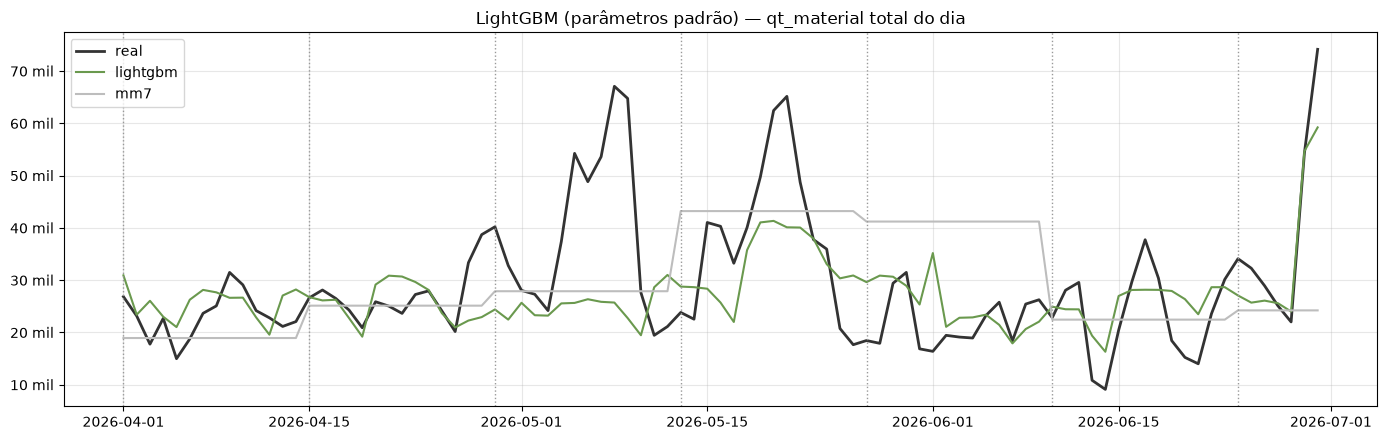

In [14]:
plot_real_previsto(["lightgbm", MELHOR_BASELINE], "LightGBM (parâmetros padrão) — qt_material total do dia")

### Esboço da árvore

O LightGBM soma dezenas a centenas de árvores, então desenhar uma delas diz pouco. Para ter um esboço legível do que o modelo aprendeu, ajustamos uma **árvore substituta** de 3 níveis que imita as previsões do LightGBM treinado com toda a base. A fidelidade (R²) mostra quanto do comportamento do modelo esse esboço captura. Os valores nas folhas estão em `qt_material` por série e dia.

Fidelidade da árvore substituta (R² contra as previsões do LightGBM): 0.55


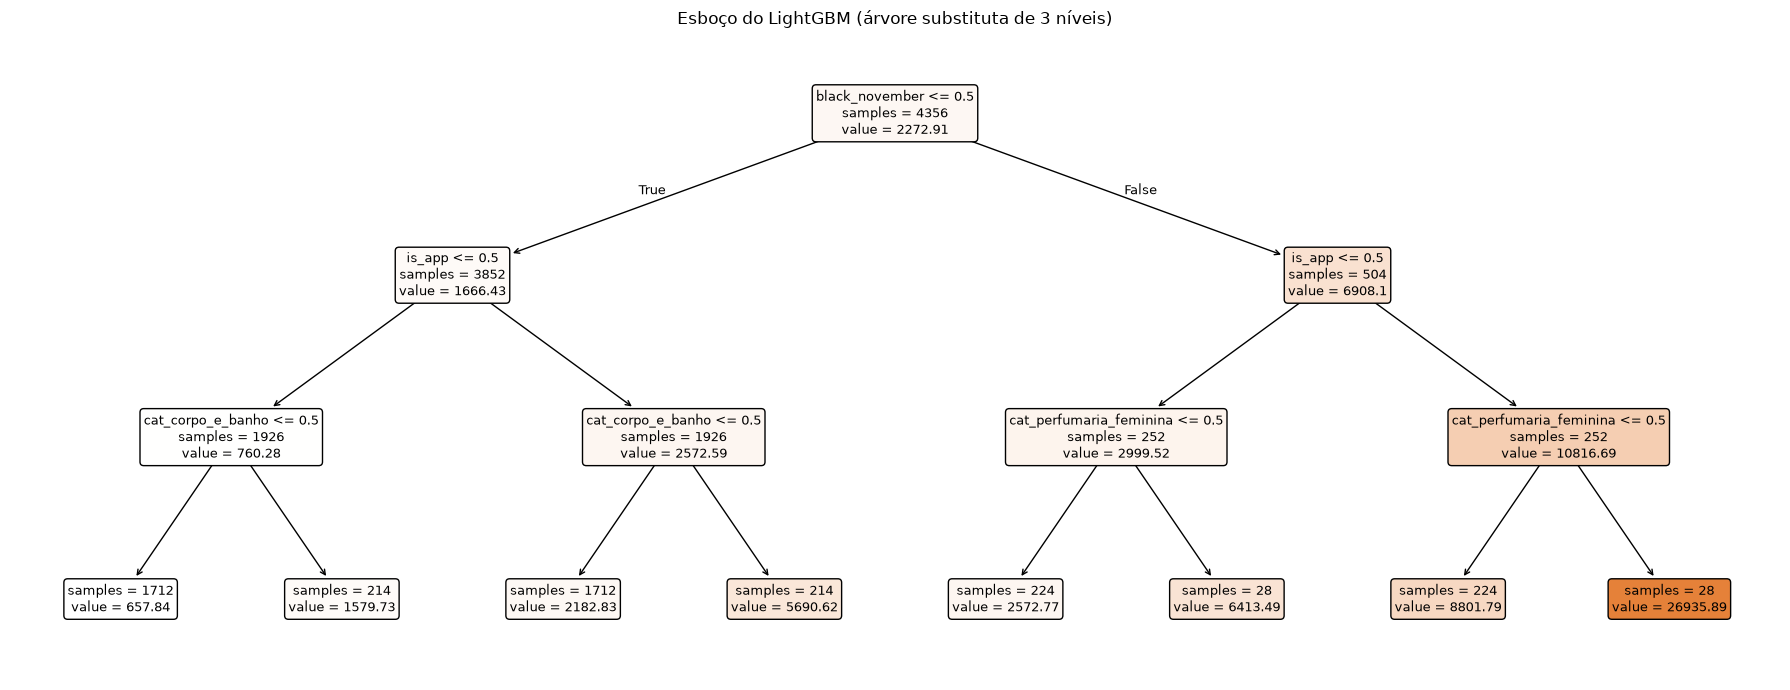

In [15]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

_, X_esboco, previsto_esboco = treinar_arvore("lightgbm", PADRAO["lightgbm"])
X_esboco = X_esboco.fillna(-1)
esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_esboco, previsto_esboco)
print(f"Fidelidade da árvore substituta (R² contra as previsões do LightGBM): "
      f"{esboco.score(X_esboco, previsto_esboco):.2f}")

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(esboco, feature_names=list(X_esboco.columns), filled=True, rounded=True,
          impurity=False, precision=2, fontsize=9, ax=ax)
ax.set_title("Esboço do LightGBM (árvore substituta de 3 níveis)")
plt.tight_layout()
plt.show()

### Diagnóstico

- **Teste faseado:** WAPE do total do dia de **25,5%**, o menor da etapa 1 (skill de 29% sobre o mm7), com viés de −7,4%. Passa no quality gate.
- **Esboço da árvore:** a primeira decisão é a **Black November**, seguida de **canal** (App vende mais) e de **categoria** (Corpo e Banho e Perfumaria Feminina). A árvore substituta explica 55% do comportamento do modelo. O resto vem do desconto semanal da categoria, do dia da semana e dos eventos, que atuam em ajustes mais finos.
- **Campanha de maio:** com a Black November separada, a previsão dessa semana caiu para ~40 mil, contra um real de até 65 mil. Antes, com a coluna única de campanha, o modelo previa até 76 mil.

## 5.3 XGBoost

### Curva: real × previsto no teste faseado

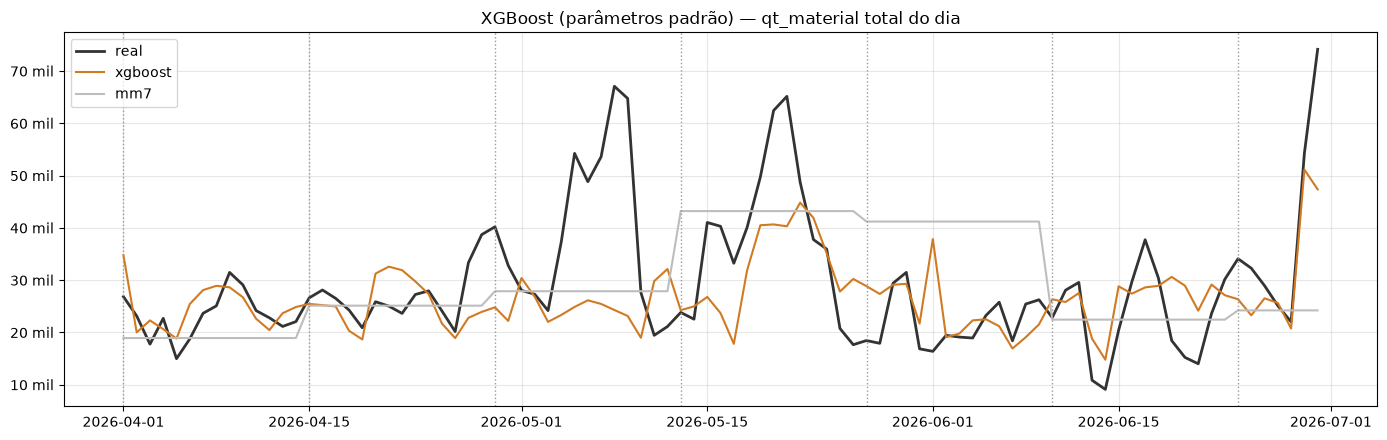

In [16]:
plot_real_previsto(["xgboost", MELHOR_BASELINE], "XGBoost (parâmetros padrão) — qt_material total do dia")

### Esboço da árvore

O XGBoost soma dezenas a centenas de árvores, então desenhar uma delas diz pouco. Para ter um esboço legível do que o modelo aprendeu, ajustamos uma **árvore substituta** de 3 níveis que imita as previsões do XGBoost treinado com toda a base. A fidelidade (R²) mostra quanto do comportamento do modelo esse esboço captura. Os valores nas folhas estão em `qt_material` por série e dia.

Fidelidade da árvore substituta (R² contra as previsões do XGBoost): 0.50


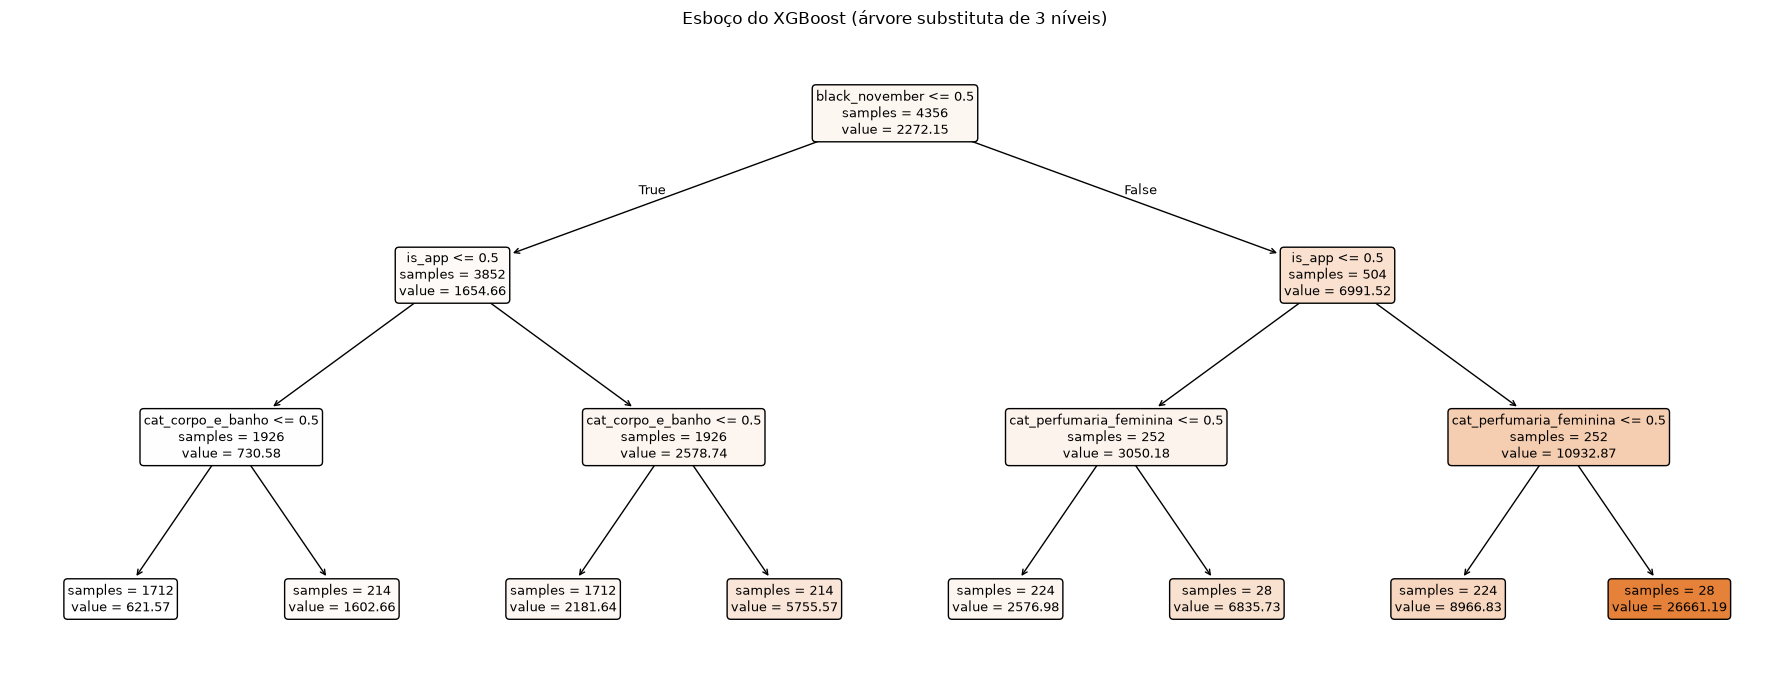

In [17]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

_, X_esboco, previsto_esboco = treinar_arvore("xgboost", PADRAO["xgboost"])
X_esboco = X_esboco.fillna(-1)
esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_esboco, previsto_esboco)
print(f"Fidelidade da árvore substituta (R² contra as previsões do XGBoost): "
      f"{esboco.score(X_esboco, previsto_esboco):.2f}")

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(esboco, feature_names=list(X_esboco.columns), filled=True, rounded=True,
          impurity=False, precision=2, fontsize=9, ax=ax)
ax.set_title("Esboço do XGBoost (árvore substituta de 3 níveis)")
plt.tight_layout()
plt.show()

### Diagnóstico

- **Teste faseado:** WAPE do total do dia de **26,4%** (skill de 26% sobre o mm7), com viés de −9,3%. Passa no quality gate por pouco.
- **Esboço da árvore:** mesma lógica do LightGBM (Black November → canal → categoria), com fidelidade de 50%.
- O comportamento é muito parecido com o do LightGBM, incluindo os mesmos acertos e os mesmos erros, como o Dia das Mães.

# 6. Comparação da etapa 1

Todos com parâmetros padrão, nas mesmas 7 rodadas de teste. O vencedor é o de menor WAPE do total do dia, e só ele segue para o ajuste da etapa 2.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.3793,0.2553,"7,514.5808",-0.0739,0.2861,True
xgboost,0.3834,0.2638,"7,763.8029",-0.0931,0.2624,True
regressao_linear,0.3770,0.2718,"8,001.6035",-0.1593,0.2398,False
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False
mm28,0.5241,0.3868,"11,384.5137",0.0169,-0.0816,False
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027,-0.1503,False


Vencedor da etapa 1: lightgbm


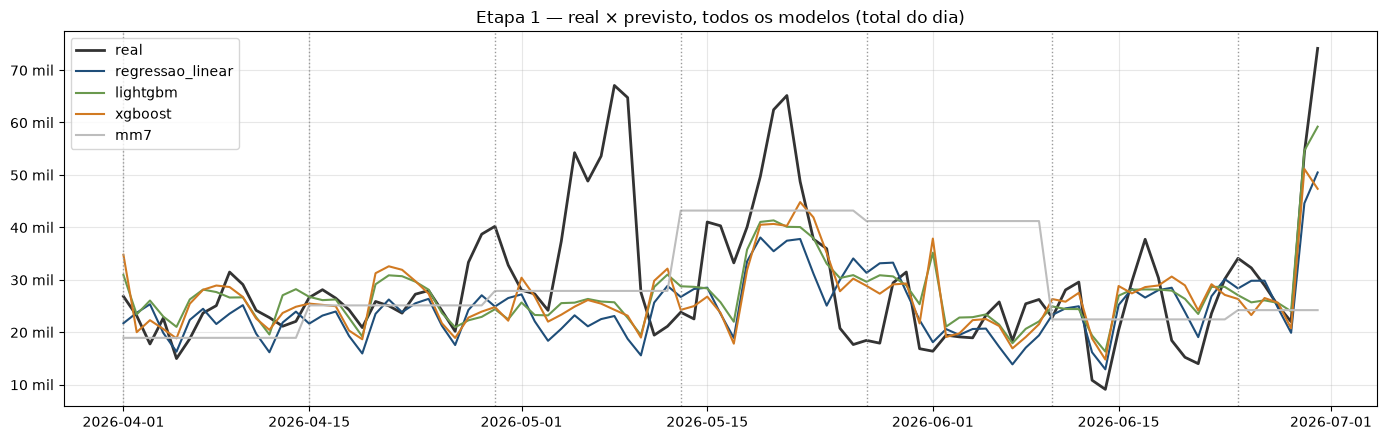

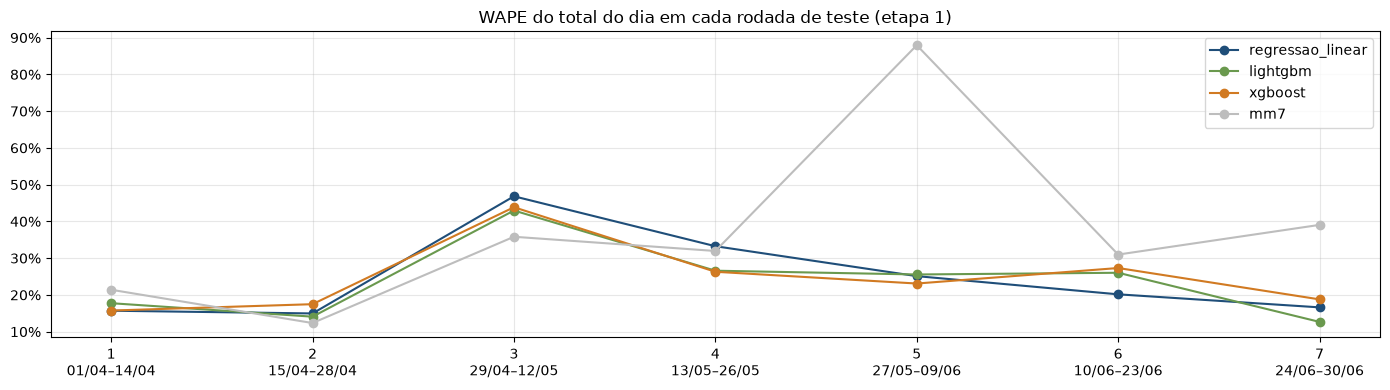

,regressao_linear,lightgbm,xgboost,mm7
rodada,,,,
1,0.1571,0.1775,0.1574,0.2141
2,0.1496,0.1408,0.1748,0.1235
3,0.4684,0.4296,0.4386,0.3582
4,0.3325,0.2659,0.2630,0.3196
5,0.2511,0.2556,0.2310,0.8794
6,0.2016,0.2603,0.2732,0.3098
7,0.1661,0.1266,0.1879,0.3906


In [18]:
def tabela_comparacao(modelos: list[str]) -> pd.DataFrame:
    tabela = pd.DataFrame({m: resumo_backtest(previsoes[m]) for m in modelos}).T
    tabela["skill_vs_baseline"] = 1 - tabela["wape_dia"] / tabela.loc[MELHOR_BASELINE, "wape_dia"]
    tabela["passa_no_gate"] = (tabela["skill_vs_baseline"] > 0) & (tabela["vies_dia"].abs() < 0.10)
    return tabela.sort_values("wape_dia")


etapa_1 = tabela_comparacao([*FABRICAS, "naive_sazonal", "mm7", "mm28"])
display(etapa_1)
VENCEDOR = etapa_1.index[etapa_1.index.isin(FABRICAS)][0]  # menor WAPE do total do dia
print(f"Vencedor da etapa 1: {VENCEDOR}")

modelos_ml = list(FABRICAS)
plot_real_previsto([*modelos_ml, MELHOR_BASELINE], "Etapa 1 — real × previsto, todos os modelos (total do dia)")

fig, ax = plt.subplots(figsize=(14, 4))
for modelo in [*modelos_ml, MELHOR_BASELINE]:
    rodadas = erro_por_rodada(previsoes[modelo])
    ax.plot(rodadas["rodada"], rodadas["wape"], marker="o", color=CORES_MODELO[modelo], label=modelo)
rotulos = [f"{r}\n{i:%d/%m}–{f:%d/%m}" for r, i, f in folds_teste[["rodada", "inicio", "fim"]].itertuples(index=False)]
ax.set_xticks(folds_teste["rodada"], rotulos)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("WAPE do total do dia em cada rodada de teste (etapa 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(pd.DataFrame({m: erro_por_rodada(previsoes[m]).set_index("rodada")["wape"]
                      for m in [*modelos_ml, MELHOR_BASELINE]}))

### Diagnóstico

- **Todos os modelos ganham dos baselines.** O LightGBM vence, com 25,5% contra 35,8% do mm7.
- **Erro ao longo do tempo:**
  - **Rodadas 1, 2, 5, 6 e 7:** erro de 13% a 27%, o comportamento normal.
  - **Rodada 3 (29/04 a 12/05):** 43–47% em todos os modelos. É a primeira vez que o Dia das Mães aparece, e nenhum modelo tinha exemplo para aprender. Até o mm7 erra menos aqui (36%).
  - **Rodada 5 (27/05 a 09/06):** o mm7 erra 88%, porque arrasta a campanha de maio para as semanas seguintes. Os modelos erram 23–26%.
- **Fim de junho:** o pico de 29–30/06, que acompanhou um salto de desconto, foi bem capturado (previsto ~59 mil contra 74 mil reais).

# 7. Etapa 2 — ajuste do vencedor rodada a rodada

Antes de cada rodada de teste, o vencedor testa todas as combinações da grade nas **3 janelas de 14 dias imediatamente anteriores** (dados até a véspera) e usa a melhor para prever a rodada. Assim os parâmetros podem mudar ao longo do tempo, e nunca são escolhidos olhando os dias que o modelo precisa acertar.

**Grades testadas**
- **Regressão linear:** `alvo` em log ou nível; com ou sem interação canal × categoria.
- **LightGBM:**
  - `num_leaves`: número máximo de folhas por árvore (complexidade de cada árvore);
  - `learning_rate` e `n_estimators`: tamanho do passo e número de árvores;
  - `min_child_samples`: mínimo de linhas por folha (evita folhas que decoram poucos dias);
  - `alvo`: log ou Poisson;
  - `usar_lags`: com ou sem o histórico da própria série.
- **XGBoost:** `max_depth` (profundidade da árvore), `learning_rate`, `n_estimators`, `min_child_weight` (peso mínimo por folha), `alvo` e `usar_lags`.

In [19]:
GRADES = {
    "regressao_linear": {"alvo": ["log", "nivel"], "interacao": [False, True]},
    "lightgbm": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "num_leaves": [7, 15, 31],
        "learning_rate": [0.03, 0.1],
        "n_estimators": [200, 500],
        "min_child_samples": [10, 40],
    },
    "xgboost": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.1],
        "n_estimators": [200, 500],
        "min_child_weight": [1, 10],
    },
}
grade = GRADES[VENCEDOR]
print(f"{VENCEDOR}: {np.prod([len(v) for v in grade.values()])} combinações por rodada")

previsoes["vencedor_ajustado"], parametros_por_rodada = backtest_com_ajuste(
    df, folds_teste, FABRICAS[VENCEDOR], grade
)
print("Parâmetros escolhidos em cada rodada (só com o passado da rodada):")
display(parametros_por_rodada)

lightgbm: 96 combinações por rodada


Parâmetros escolhidos em cada rodada (só com o passado da rodada):


,rodada,alvo,usar_lags,num_leaves,learning_rate,n_estimators,min_child_samples,wape_serie_ajuste
0,1,poisson,False,31,0.0300,500,10,0.3785
1,2,poisson,False,31,0.0300,500,40,0.3656
2,3,poisson,False,15,0.1000,200,40,0.3096
3,4,poisson,True,7,0.1000,500,40,0.3807
4,5,poisson,False,31,0.0300,500,10,0.3916
5,6,poisson,False,15,0.0300,500,40,0.4152
6,7,poisson,False,7,0.1000,500,40,0.3735


In [20]:
etapa_2 = tabela_comparacao([VENCEDOR, "vencedor_ajustado", MELHOR_BASELINE])
etapa_2 = etapa_2.rename(index={VENCEDOR: f"{VENCEDOR} (padrão)", "vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(etapa_2)

wape_rodada = pd.DataFrame({
    f"{VENCEDOR} (padrão)": erro_por_rodada(previsoes[VENCEDOR]).set_index("rodada")["wape"],
    f"{VENCEDOR} (ajustado)": erro_por_rodada(previsoes["vencedor_ajustado"]).set_index("rodada")["wape"],
})
display(wape_rodada)

AJUSTE_AJUDA = (resumo_backtest(previsoes["vencedor_ajustado"])["wape_dia"]
                < resumo_backtest(previsoes[VENCEDOR])["wape_dia"])
print("O ajuste reduz o erro?", "sim — o modelo final usa parâmetros ajustados" if AJUSTE_AJUDA
      else "não — o modelo final fica com os parâmetros padrão")

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm (padrão),0.3793,0.2553,"7,514.5808",-0.0739,0.2861,True
lightgbm (ajustado),0.3973,0.2767,"8,143.4011",-0.0996,0.2263,True
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False


,lightgbm (padrão),lightgbm (ajustado)
rodada,,
1,0.1775,0.1987
2,0.1408,0.1483
3,0.4296,0.4797
4,0.2659,0.3002
5,0.2556,0.2752
6,0.2603,0.2487
7,0.1266,0.1244


O ajuste reduz o erro? não — o modelo final fica com os parâmetros padrão


### Parâmetros do modelo final

Para produção, aplicamos o mesmo procedimento na data de hoje: a grade é testada nas 3 janelas de 14 dias mais recentes da base (até 30/06). Se a etapa 2 mostrou que o ajuste não reduz o erro, o modelo final fica com os parâmetros padrão.

In [21]:
if AJUSTE_AJUDA:
    proximo_dia = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
    busca_final = buscar_parametros(df, folds_de_ajuste(proximo_dia), FABRICAS[VENCEDOR], grade)
    PARAMETROS_FINAIS = {k: (v.item() if hasattr(v, "item") else v) for k, v in busca_final.loc[0, list(grade)].items()}
    print("Melhores combinações nas 3 janelas mais recentes:")
    display(busca_final.head(5))
else:
    PARAMETROS_FINAIS = PADRAO[VENCEDOR]
print(f"Modelo final: {VENCEDOR} com {PARAMETROS_FINAIS}")

Modelo final: lightgbm com {'alvo': 'poisson', 'usar_lags': False}


### Diagnóstico

- **O ajuste rodada a rodada piorou o LightGBM:** WAPE de 27,7% contra 25,5% com os parâmetros padrão. Ele perdeu em 5 das 7 rodadas.
- **Motivo:** as 3 janelas anteriores a cada rodada somam só 42 dias. A combinação que vence ali se adapta a esse período curto e não se repete nas 2 semanas seguintes. Os parâmetros escolhidos mudam quase toda rodada (`num_leaves` entre 7 e 31, com e sem lags), sinal de que a escolha é instável.
- **O que a etapa 2 confirmou:**
  - o objetivo **Poisson** venceu em todas as rodadas;
  - **sem lags** venceu em 6 de 7.
- **Decisão:** o modelo final fica com os **parâmetros padrão**. Com mais histórico (janelas de ajuste maiores), vale repetir a etapa 2.

# 8. Resultado final

Comparação de tudo que rodou no teste faseado (01/04 a 30/06).

**Quality gate** para seguir com um modelo: skill > 0 contra o melhor baseline e |viés| < 10% no total do dia.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.3793,0.2553,"7,514.5808",-0.0739,0.2861,True
xgboost,0.3834,0.2638,"7,763.8029",-0.0931,0.2624,True
regressao_linear,0.3770,0.2718,"8,001.6035",-0.1593,0.2398,False
lightgbm (ajustado),0.3973,0.2767,"8,143.4011",-0.0996,0.2263,True
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False
mm28,0.5241,0.3868,"11,384.5137",0.0169,-0.0816,False
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027,-0.1503,False


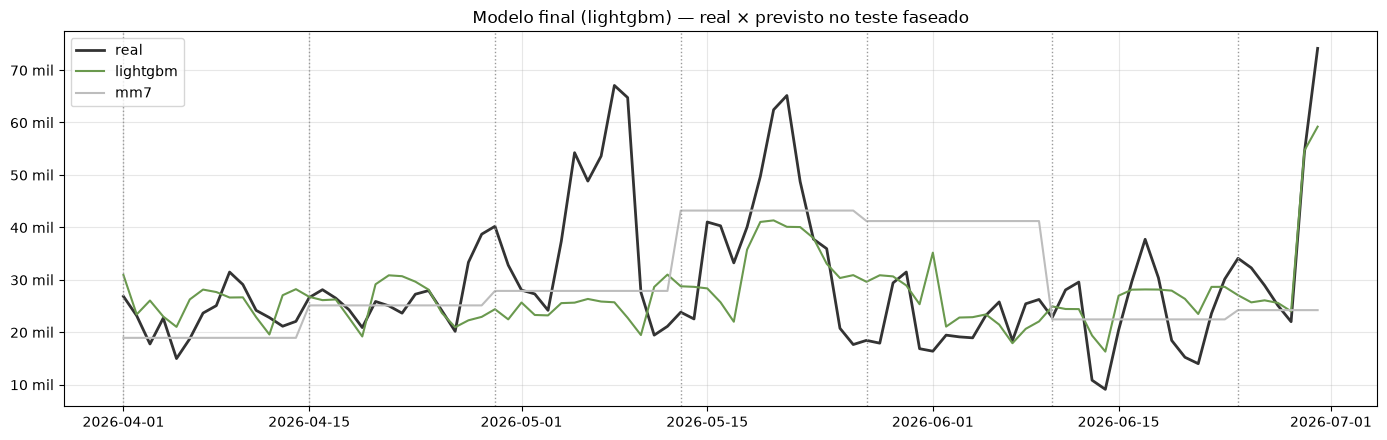

WAPE por categoria × canal — modelo final (lightgbm)


des_canal_venda_final_agrup,App,Site
des_categoria_material,,
CABELOS,36.0%,44.1%
CORPO E BANHO,37.9%,37.5%
FACIAL,64.7%,85.6%
GIFTS,40.7%,33.6%
MAQUIAGEM,35.1%,45.3%
NAO_IDENTIFICADA,73.1%,76.9%
PERF. DE ENTRADA E DEOS,25.7%,29.0%
PERFUMARIA FEMININA,35.5%,45.4%
PERFUMARIA MASCULINA,40.8%,36.2%


In [22]:
final = tabela_comparacao([*FABRICAS, "vencedor_ajustado", "naive_sazonal", "mm7", "mm28"])
final = final.rename(index={"vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(final)

MODELO_FINAL = "vencedor_ajustado" if AJUSTE_AJUDA else VENCEDOR
plot_real_previsto([MODELO_FINAL, MELHOR_BASELINE], f"Modelo final ({VENCEDOR}) — real × previsto no teste faseado")

melhor = previsoes[MODELO_FINAL]
erro_serie = (
    melhor.assign(erro_abs=(melhor["previsto"] - melhor["qt_material"]).abs())
    .groupby(["des_categoria_material", "des_canal_venda_final_agrup"])[["erro_abs", "qt_material"]].sum()
)
erro_serie = (erro_serie["erro_abs"] / erro_serie["qt_material"]).unstack()
print(f"WAPE por categoria × canal — modelo final ({VENCEDOR})")
display(erro_serie.map(lambda v: f"{v:.1%}"))

### Diagnóstico

- **Modelo final:** LightGBM com parâmetros padrão e objetivo Poisson. WAPE do total do dia de **25,5%**, contra 35,8% do melhor baseline (ganho de 29%), com viés de −7,4%. Passa no quality gate.
- **Por série:**
  - menor erro nas categorias grandes e estáveis: Perf. de Entrada e Deos (26–29%), Corpo e Banho (~38%);
  - maior erro em Facial (65–86%) e `NAO_IDENTIFICADA` (73–77%), que são séries pequenas e ruidosas.
  - Para planejamento, o total do dia e as categorias grandes são os números confiáveis.

# 9. SHAP — impacto de cada feature

O SHAP decompõe cada previsão em contribuições de cada feature: quanto cada uma empurrou a previsão para cima ou para baixo em relação à média. Usamos os modelos treinados com toda a base: o vencedor com os parâmetros finais e os demais com os parâmetros padrão.

- **Gráfico de pontos (beeswarm):** cada ponto é uma linha da base. A cor é o valor da feature (vermelho = alto) e a posição é o impacto na previsão.
- **Gráfico de barras:** impacto médio absoluto, com as dummies de categoria somadas em `categoria` e as de dia da semana em `dia_semana`, para comparar os três modelos. Como os modelos usam escalas diferentes (log, Poisson), comparamos a **participação %** de cada feature.

/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


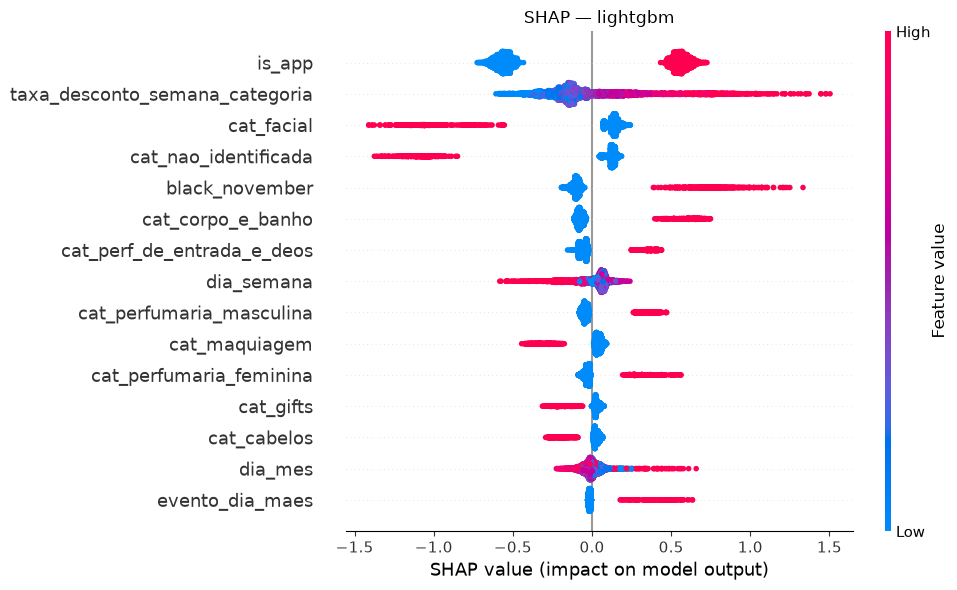

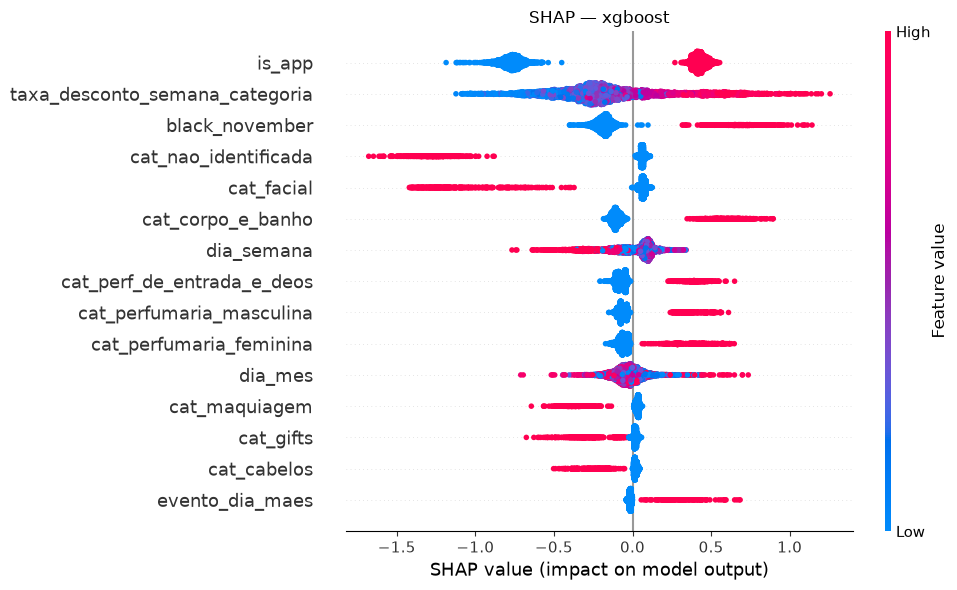

In [23]:
import shap

from gb_ml.features import matriz_linear

parametros_shap = {nome: (PARAMETROS_FINAIS if nome == VENCEDOR else PADRAO[nome]) for nome in FABRICAS}

valores_shap = {}
for nome in ["lightgbm", "xgboost"]:
    modelo, X, _ = treinar_arvore(nome, parametros_shap[nome])
    valores_shap[nome] = (shap.TreeExplainer(modelo).shap_values(X), X)
    plt.figure()
    shap.summary_plot(valores_shap[nome][0], X, max_display=15, show=False, plot_size=(10, 6))
    plt.title(f"SHAP — {nome}")
    plt.tight_layout()
    plt.show()

modelo_linear_shap = ajustar_linear(df, **parametros_shap["regressao_linear"])
X_linear = matriz_linear(df, parametros_shap["regressao_linear"]["interacao"])[modelo_linear_shap.params.index.drop("const")]
# SHAP de modelo linear: coeficiente × (valor − média)
valores_shap["regressao_linear"] = (((X_linear - X_linear.mean()) * modelo_linear_shap.params.drop("const")).to_numpy(), X_linear)

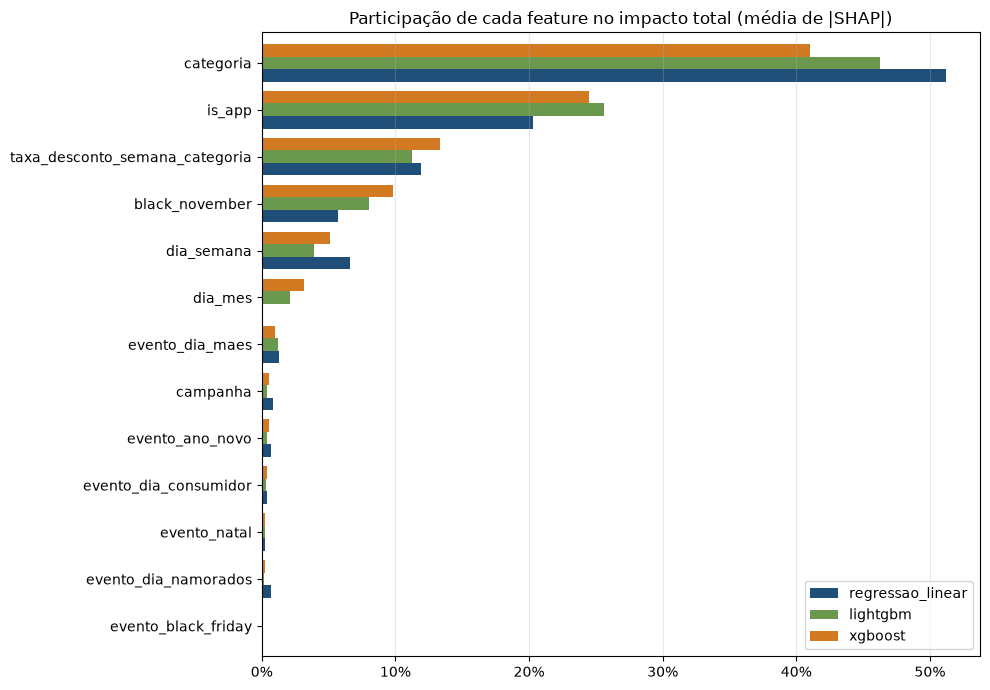

,regressao_linear,lightgbm,xgboost
categoria,51.2%,46.3%,41.1%
is_app,20.3%,25.6%,24.5%
taxa_desconto_semana_categoria,11.9%,11.3%,13.3%
black_november,5.7%,8.1%,9.8%
dia_semana,6.6%,3.9%,5.1%
dia_mes,0.0%,2.1%,3.1%
evento_dia_maes,1.3%,1.3%,1.0%
campanha,0.8%,0.4%,0.5%
evento_ano_novo,0.7%,0.4%,0.5%
evento_dia_consumidor,0.4%,0.3%,0.4%


In [24]:
def agrupar(nome_coluna: str) -> str:
    if nome_coluna.startswith(("cat_", "app_x_cat_")):
        return "categoria"
    if nome_coluna.startswith("dia_semana"):
        return "dia_semana"
    if nome_coluna.startswith(("lag_", "mm")):
        return "lags (histórico)"
    return nome_coluna


importancia = {}
for nome in ["regressao_linear", "lightgbm", "xgboost"]:
    valores, X = valores_shap[nome]
    impacto = pd.Series(np.abs(valores).mean(axis=0), index=X.columns)
    impacto = impacto.groupby(impacto.index.map(agrupar)).sum()
    importancia[nome] = impacto / impacto.sum()
importancia = pd.DataFrame(importancia).fillna(0).sort_values("lightgbm")

ax = importancia.plot.barh(figsize=(10, 7), color=[CORES_MODELO[m] for m in importancia.columns], width=0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Participação de cada feature no impacto total (média de |SHAP|)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
display(importancia.sort_values("lightgbm", ascending=False).map(lambda v: f"{v:.1%}"))

### Diagnóstico

- **Os três modelos concordam na ordem de importância:**
  - **Categoria e canal** explicam cerca de 70% do impacto. São o nível de cada série.
  - **Desconto semanal da categoria** (11–13%) e **Black November** (6–10%) explicam a variação ao longo do tempo.
  - **Dia da semana** fica com 4–7%.
- **Desconto:** no beeswarm do LightGBM, desconto alto (vermelho) empurra a previsão para cima, com efeito crescente nas taxas mais altas.
- **Eventos:** pesam pouco na média porque ficam ligados em poucos dias, mas nesses dias o impacto é grande (Dia das Mães, Ano Novo negativo).
- **Black Friday:** a flag da semana tem impacto ~0% nos três modelos. O pico de novembro é atribuído à coluna `black_november` e ao desconto. Para a próxima Black Friday, o que carrega o efeito é a Black November, que já é calculada por regra para 2026.

# 10. Sensibilidade à premissa do desconto

No backtest usamos a taxa **realizada** de cada categoria na semana, como se o time de desconto acertasse a previsão em cheio. Para medir o risco de um plano menos detalhado, refazemos o teste trocando a taxa **só nos dias previstos** (o treino continua igual):
- **semanal sem abertura por categoria:** todas as categorias recebem a taxa média da semana do total;
- **mensal por categoria:** cada categoria recebe a sua taxa média do mês, sem os picos de cada semana.

In [25]:
def taxa(agrupamento) -> pd.Series:
    grupo = df.groupby(agrupamento)
    desconto = grupo["vlr_venda_desconto"].transform("sum")
    return desconto / (grupo["receita_aprovada"].transform("sum") + desconto)


semana = df["data"].dt.to_period("W-SUN")
mes = df["data"].dt.to_period("M")
CENARIOS = {
    "semanal sem abertura por categoria": taxa(semana),
    "mensal por categoria": taxa([mes, df["des_categoria_material"]]),
}


def com_desconto(ajustar_prever, taxa_cenario):
    def ajustar_prever_cenario(treino, teste):
        return ajustar_prever(treino, teste.assign(**{COLUNA_DESCONTO: taxa_cenario.loc[teste.index]}))
    return ajustar_prever_cenario


sensibilidade = []
for nome in FABRICAS:
    linha = {"modelo": nome, "premissa (semanal por categoria)": resumo_backtest(previsoes[nome])["wape_dia"]}
    for cenario, taxa_cenario in CENARIOS.items():
        resultado = resumo_backtest(rodar_backtest(df, folds_teste, com_desconto(FABRICAS[nome](**PADRAO[nome]), taxa_cenario)))
        linha[cenario] = resultado["wape_dia"]
    sensibilidade.append(linha)
sensibilidade = pd.DataFrame(sensibilidade).set_index("modelo")
sensibilidade[f"{MELHOR_BASELINE} (sem desconto)"] = resumo_baselines.loc[MELHOR_BASELINE, "wape_dia"]
print("WAPE do total do dia (parâmetros padrão)")
display(sensibilidade.map(lambda v: f"{v:.1%}"))

WAPE do total do dia (parâmetros padrão)


,premissa (semanal por categoria),semanal sem abertura por categoria,mensal por categoria,mm7 (sem desconto)
modelo,,,,
regressao_linear,27.2%,25.9%,30.0%,35.8%
lightgbm,25.5%,26.8%,30.7%,35.8%
xgboost,26.4%,29.5%,30.8%,35.8%


### Diagnóstico

- **Plano semanal sem abertura por categoria:** o LightGBM piora 1,3 p.p. (de 25,5% para 26,8%) e o XGBoost 3,1 p.p. A regressão linear até melhora (de 27,2% para 25,9%), porque é sensível a picos de desconto de categorias pequenas.
- **Plano mensal por categoria:** todos ficam em torno de 30–31%. Perder o detalhe da semana custa cerca de 5 p.p.
- **Conclusão:** o detalhe **semanal** é o que mais importa na premissa. A abertura por categoria ajuda as árvores, mas é secundária. Mesmo no pior cenário, todos os modelos continuam melhores que o mm7 (35,8%).

# 11. Conclusões e próximos passos

**Resultado**
- **Modelo recomendado: LightGBM com parâmetros padrão e objetivo Poisson.** No teste faseado de 01/04 a 30/06, o WAPE do total do dia foi de **25,5%**, contra 35,8% do melhor baseline (ganho de 29%), com viés de −7,4%. Passa no quality gate.
- **Regressão linear como modelo de apoio:** erra um pouco mais (27,2%) e subestima mais, mas explica cada efeito com intervalo de confiança. É a melhor ferramenta para conversar com o negócio ("+10 p.p. de desconto na categoria ≈ +47% de volume"; "Black November ≈ +127%").

**O que mudou em relação à primeira versão**
- **Black November em coluna própria:** acabou a superestimação da campanha de maio.
- **Desconto semanal por categoria:** com os mesmos parâmetros padrão, o LightGBM caiu de 27,5% para 25,5%.

**O que testamos e não usamos**
- **Lags:** pioram ou não ajudam.
- **Ajuste fino de hiperparâmetros:** com 42 dias de janela, se adapta ao período recente e piora o teste.
- **Mês e ano:** com 8 meses de base, o modelo decoraria cada mês. Devem entrar quando houver 2 anos de dados.

**Estaremos preparados para a próxima Black Friday?** Em parte:
- A Black November e as datas comemorativas são calculadas por regra, então 2026 já tem flags (Black November de 02 a 29/11/2026).
- O efeito aprendido vem de uma única ocorrência, e o Dia das Mães mostrou o risco: na primeira vez que um evento aparece, o modelo erra muito.
- Os efeitos devem ser reestimados após cada nova ocorrência.

**Próximos passos**
1. **Agregar a previsão das séries pequenas** (Facial, `NAO_IDENTIFICADA`) num nível mais alto, ou reconciliar com o total, já que o erro delas é alto.
2. **Gravar previsões e métricas de cada execução no BigQuery** (com id_execucao, data e versão do código) e monitorar o WAPE semana a semana contra o baseline.
3. **Retreinar quinzenalmente** (o mesmo ritmo do teste faseado) e repetir a etapa 2 quando houver mais histórico.
4. **Incluir mês e ano quando a base tiver 2 anos ou mais.**